In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading and Exploring the mortality_training_data.csv

In [127]:
mortality_training_data = pd.read_csv('backend\\data\\mortality_training_data.csv')

mortality_training_data.head()

,customer_id,age,gender,height_cm,weight_kg,bmi,bmi_category,occupation,occupation_risk,smoker_status,...,base_mortality_probability,bmi_multiplier,occupation_multiplier,lifestyle_multiplier,health_multiplier,medical_extra_loading,mortality_probability,mortality_score,mortality_category,mortality_event
0,MORT0000001,44,Female,153.4,52.4,22.3,Normal Weight,Demolition Worker,High,0,...,0.002345,1.00,2.4,1.0500,0.85,0.0,0.004270,21.35,Low,0
1,MORT0000002,28,Male,170.3,99.8,34.4,Obese Class I,Real Estate Agent,Medium,1,...,0.000942,1.50,1.2,1.8375,1.00,0.0,0.003583,17.92,Low,0
2,MORT0000003,50,Male,165.5,76.9,28.1,Overweight,Racing Driver (Professional),High,0,...,0.004436,1.15,2.6,1.0500,0.85,0.0,0.013613,39.36,Medium,0
3,MORT0000004,52,Male,173.1,73.8,24.6,Normal Weight,Armed Forces Personnel (Combat),High,0,...,0.005550,1.00,2.5,0.9500,0.85,0.0,0.012885,38.14,Medium,0
4,MORT0000005,18,Female,162.2,50.6,19.2,Normal Weight,Teacher,Low,0,...,0.000874,1.00,1.0,1.0500,0.85,0.0,0.000663,3.32,Low,0


In [5]:
print(mortality_training_data.value_counts('mortality_event'))

print(mortality_training_data.value_counts('mortality_event', normalize=True)*100)

mortality_event
0    49548
1      452
Name: count, dtype: int64
mortality_event
0    99.096
1     0.904
Name: proportion, dtype: float64


In [6]:
print(mortality_training_data.groupby("mortality_event")["mortality_probability"].describe())

print(mortality_training_data.groupby("mortality_event")["mortality_score"].describe())

                   count      mean       std       min       25%       50%  \
mortality_event                                                              
0                49548.0  0.008620  0.015323  0.000528  0.001944  0.003750   
1                  452.0  0.041372  0.058224  0.000594  0.008616  0.021463   

                      75%       max  
mortality_event                      
0                0.008708  0.512118  
1                0.051275  0.457137  
                   count       mean        std   min      25%    50%    75%  \
mortality_event                                                               
0                49548.0  23.427691  17.260001  2.64   9.7200  18.75  31.18   
1                  452.0  49.709889  22.250246  2.97  31.0275  51.22  75.04   

                   max  
mortality_event         
0                87.84  
1                86.31  


In [7]:
mortality_training_data.isnull().sum()

customer_id                   0
age                           0
gender                        0
height_cm                     0
weight_kg                     0
bmi                           0
bmi_category                  0
occupation                    0
occupation_risk               0
smoker_status                 0
alcohol_use                   0
exercise_level                0
diabetes                      0
hypertension                  0
heart_disease                 0
respiratory_disease           0
cancer_history                0
health_status                 0
base_mortality_probability    0
bmi_multiplier                0
occupation_multiplier         0
lifestyle_multiplier          0
health_multiplier             0
medical_extra_loading         0
mortality_probability         0
mortality_score               0
mortality_category            0
mortality_event               0
dtype: int64

In [8]:
print(mortality_training_data.groupby("mortality_event")["age"].describe())

                   count       mean        std   min   25%   50%   75%   max
mortality_event                                                             
0                49548.0  40.498648  11.580696  18.0  32.0  40.0  48.0  70.0
1                  452.0  52.858407  11.035614  18.0  46.0  54.0  61.0  70.0


In [13]:
print(pd.crosstab(
    pd.cut(mortality_training_data["age"], bins=[18,30,40,50,60,70,80]),
    mortality_training_data["mortality_event"],
    normalize="index"
))

mortality_event         0         1
age                                
(18, 30]         0.998447  0.001553
(30, 40]         0.996815  0.003185
(40, 50]         0.992805  0.007195
(50, 60]         0.979351  0.020649
(60, 70]         0.949837  0.050163


In [14]:
print(mortality_training_data.groupby("mortality_event")["bmi"].describe())

                   count       mean       std   min   25%   50%   75%   max
mortality_event                                                            
0                49548.0  24.855599  4.617695  14.8  21.7  24.8  28.0  44.7
1                  452.0  25.120796  5.425015  14.8  21.4  25.2  28.9  39.8


In [15]:
print(pd.crosstab(
    mortality_training_data["smoker_status"],
    mortality_training_data["mortality_event"],
    normalize="index"
))

mortality_event         0         1
smoker_status                      
0                0.992426  0.007574
1                0.983434  0.016566


In [12]:
for col in [
    "diabetes",
    "hypertension",
    "heart_disease",
    "respiratory_disease",
    "cancer_history"
]:
    print(col)
    print(
        pd.crosstab(
            mortality_training_data[col],
            mortality_training_data["mortality_event"],
            normalize="index"
        )
    )

diabetes
mortality_event         0         1
diabetes                           
0                0.992148  0.007852
1                0.974601  0.025399
hypertension
mortality_event         0         1
hypertension                       
0                0.991976  0.008024
1                0.980383  0.019617
heart_disease
mortality_event         0         1
heart_disease                      
0                0.991625  0.008375
1                0.962995  0.037005
respiratory_disease
mortality_event             0         1
respiratory_disease                    
0                    0.991179  0.008821
1                    0.986118  0.013882
cancer_history
mortality_event         0         1
cancer_history                     
0                0.991168  0.008832
1                0.974684  0.025316


In [18]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    mortality_training_data["mortality_event"],
    mortality_training_data["age"]
)

0.7825641141047817

In [19]:
print(pd.crosstab(
    mortality_training_data["bmi_category"],
    mortality_training_data["mortality_event"],
    normalize="index"
))

mortality_event                  0         1
bmi_category                                
Mild Thinness             0.990263  0.009737
Moderate Thinness         0.981567  0.018433
Normal Weight             0.992585  0.007415
Obese Class I             0.988661  0.011339
Obese Class II            0.967436  0.032564
Obese Class III (Morbid)  1.000000  0.000000
Overweight                0.991818  0.008182
Severe Thinness           0.984911  0.015089


In [23]:
print(mortality_training_data["bmi_category"].value_counts())

bmi_category
Normal Weight               21038
Overweight                  17722
Obese Class I                6085
Mild Thinness                2054
Severe Thinness              1458
Moderate Thinness             868
Obese Class II                737
Obese Class III (Morbid)       38
Name: count, dtype: int64


In [24]:
features = [
    "age",
    "bmi",
    "gender",
    "occupation_risk",
    "alcohol_use",
    "exercise_level",
    "smoker_status",
    "diabetes",
    "hypertension",
    "heart_disease",
    "respiratory_disease",
    "cancer_history"
]

X = mortality_training_data[features]
y = mortality_training_data["mortality_event"]

In [25]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.select_dtypes(include="object").columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

C:\Users\kar99\AppData\Local\Temp\ipykernel_23864\3655004424.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_encoded.select_dtypes(include="object").columns:


In [27]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_encoded,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Mutual Information": mi_scores
})

print(mi_df.sort_values(
    "Mutual Information",
    ascending=False
))

                Feature  Mutual Information
2                gender            0.007583
0                   age            0.005755
5        exercise_level            0.005476
3       occupation_risk            0.004801
4           alcohol_use            0.004021
6         smoker_status            0.001748
1                   bmi            0.001147
9         heart_disease            0.000677
7              diabetes            0.000462
10  respiratory_disease            0.000203
8          hypertension            0.000144
11       cancer_history            0.000000


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_encoded, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [29]:
importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

                Feature  Importance
0                   age    0.398463
1                   bmi    0.289480
5        exercise_level    0.059494
3       occupation_risk    0.057722
4           alcohol_use    0.056350
2                gender    0.033074
6         smoker_status    0.025743
7              diabetes    0.024350
8          hypertension    0.019911
10  respiratory_disease    0.014553
9         heart_disease    0.014491
11       cancer_history    0.006369


In [30]:
print(mortality_training_data["heart_disease"].value_counts())

print(mortality_training_data["heart_disease"].value_counts(normalize=True))

heart_disease
0    48838
1     1162
Name: count, dtype: int64
heart_disease
0    0.97676
1    0.02324
Name: proportion, dtype: float64


In [31]:
for col in [
    "gender",
    "occupation_risk",
    "alcohol_use",
    "exercise_level"
]:
    print("\n", col)
    print(
        pd.crosstab(
            mortality_training_data[col],
            mortality_training_data["mortality_event"],
            normalize="index"
        )
    )


 gender
mortality_event         0         1
gender                             
Female           0.991704  0.008296
Male             0.990280  0.009720

 occupation_risk
mortality_event         0         1
occupation_risk                    
High             0.985788  0.014212
Low              0.993869  0.006131
Medium           0.993292  0.006708

 alcohol_use
mortality_event         0         1
alcohol_use                        
Heavy            0.988718  0.011282
Moderate         0.990913  0.009087
No Alcohol       0.991876  0.008124

 exercise_level
mortality_event         0         1
exercise_level                     
High             0.993661  0.006339
Low              0.987223  0.012777
Medium           0.992131  0.007869


---
## Metrics used for evaluating the models

### 1. ROC-AUC
- Receiver-operating characteristic curve.
- This curve is calculated by true positive rate (TPR) and false positive rate (FPR) at select intervals.
- TPR/FPR graph 
- Area Under Curve
- Given randomly chosen positive and negative examples, the probability that the model ranks the positive example higher than the negative is represented by the AUC
- The higher the better
- Relevance to our model:
- Person with high death probability should rank more than the person with low probability in terms of risk.
- This metric shows us how well the model ranks an individual with high death probability vs an individual with low death probability.

### 2. PR-AUC
- Precision Recall
- Precision: proportion of true positives out of all positives TP/(TP + FP)
- Recall: proportion of true positives out of all actual positives TP/(TP+ FN)
- Useful for imbalanced datasets where one class is outnumbering the other class significantly
- PR curve is created by changing the decision threshold of the model and checking how the precision and recall responds. 
- A threshold is the cutoff point we can decide, above which is positive prediction and below the point is negative prediction
- The higher the better
- Relevance to our model:
- It allows us to see when our model is predicting high risk, how often it is actually finding deaths
    
### 3. Brier Score
- Score to determine the accuracy of the probabilistic prediction.
- Often the mean squared error.
- Square of the difference between prediction and the actual result is taken at intervals and its average is calculated
- The lesser the better.
- Relevance to our model:
- The brier score tells us how little difference is there between the predicted probability of death and actual probability of death
    

## Building models
---
#### Baseline model - 1: Logistic Regression

In [34]:
features = [
    "age",
    "bmi",
    "gender",
    "occupation_risk",
    "alcohol_use",
    "exercise_level",
    "smoker_status",
    "diabetes",
    "hypertension",
    "heart_disease",
    "respiratory_disease",
    "cancer_history"
]

target = "mortality_event"

X = mortality_training_data[features]
y = mortality_training_data[target]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

mortality_event
0    0.99085
1    0.00915
Name: proportion, dtype: float64
mortality_event
0    0.9914
1    0.0086
Name: proportion, dtype: float64


In [36]:
numeric_features = [
    "age",
    "bmi"
]

categorical_features = [
    "gender",
    "occupation_risk",
    "alcohol_use",
    "exercise_level"
]

binary_features = [
    "smoker_status",
    "diabetes",
    "hypertension",
    "heart_disease",
    "respiratory_disease",
    "cancer_history"
]

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "bin",
            "passthrough",
            binary_features
        )
    ]
)

In [50]:
from sklearn.linear_model import LogisticRegression

log_reg_1 = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

In [51]:
pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier", log_reg_1)
])

In [52]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','bmi','gender',...,'heart_disease','respiratory_disease', 'cancer_history']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [53]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8437592364098692


In [55]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:",pr_auc)

PR-AUC: 0.09841093450076878


In [56]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)
print("Brier score:",brier)

Brier score: 0.1736828647852195


In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.74      0.85      9914
           1       0.03      0.76      0.05        86

    accuracy                           0.74     10000
   macro avg       0.51      0.75      0.45     10000
weighted avg       0.99      0.74      0.85     10000



In [58]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[7380 2534]
 [  21   65]]


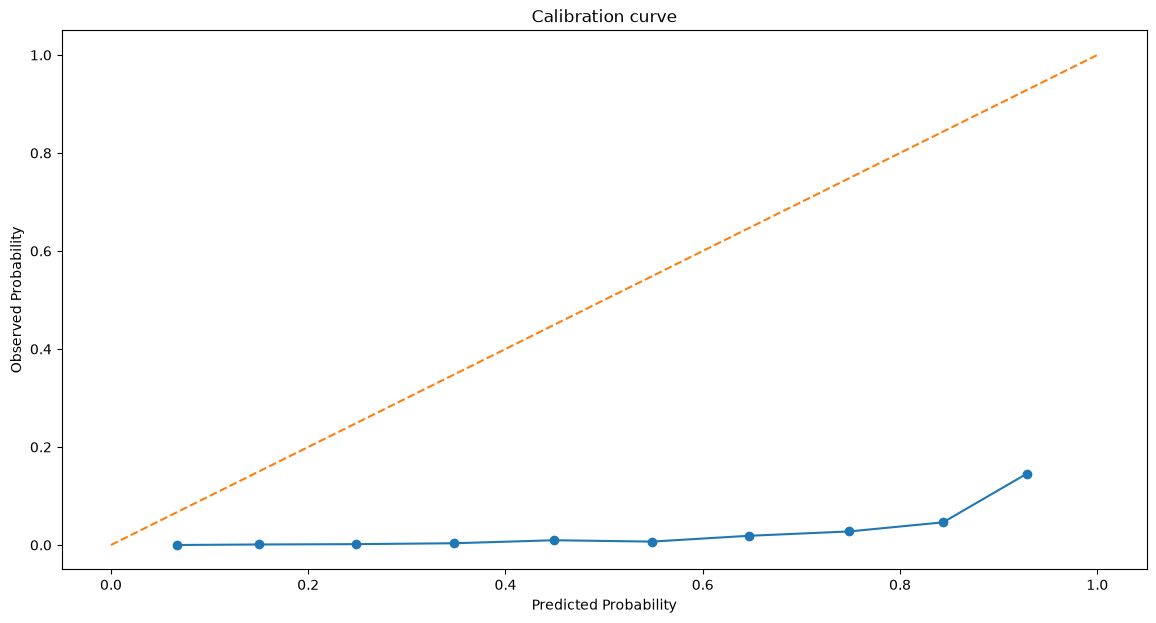

In [59]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(14,7))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration curve")
plt.show()

In [60]:
feature_names = (
    pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    pipeline.named_steps["classifier"]
    .coef_[0]
)

In [61]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    "Coefficient",
    ascending=False
)

print(coef_df.head(20))

                        Feature  Coefficient
0                      num__age     0.962047
16           bin__heart_disease     0.757386
13           bin__smoker_status     0.698608
14                bin__diabetes     0.657683
17     bin__respiratory_disease     0.605329
11      cat__exercise_level_Low     0.413863
15            bin__hypertension     0.374599
4     cat__occupation_risk_High     0.364655
18          bin__cancer_history     0.213016
7        cat__alcohol_use_Heavy     0.112371
1                      num__bmi     0.028841
8     cat__alcohol_use_Moderate    -0.148011
3              cat__gender_Male    -0.157057
2            cat__gender_Female    -0.225408
12   cat__exercise_level_Medium    -0.246032
6   cat__occupation_risk_Medium    -0.342651
9   cat__alcohol_use_No Alcohol    -0.346825
5      cat__occupation_risk_Low    -0.404469
10     cat__exercise_level_High    -0.550296


ROC-AUC: 0.844221350122683
PR-AUC: 0.09661709401004771
Brier score: 0.008171421402725339
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9914
           1       0.00      0.00      0.00        86

    accuracy                           0.99     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.98      0.99      0.99     10000

[[9914    0]
 [  86    0]]


d:\Karthikeya\Projects\AgenticAIwithGoogleADK\LifeInsuranceProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Karthikeya\Projects\AgenticAIwithGoogleADK\LifeInsuranceProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Karthikeya\Projects\AgenticAIwithGoogleADK\LifeInsuranceProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

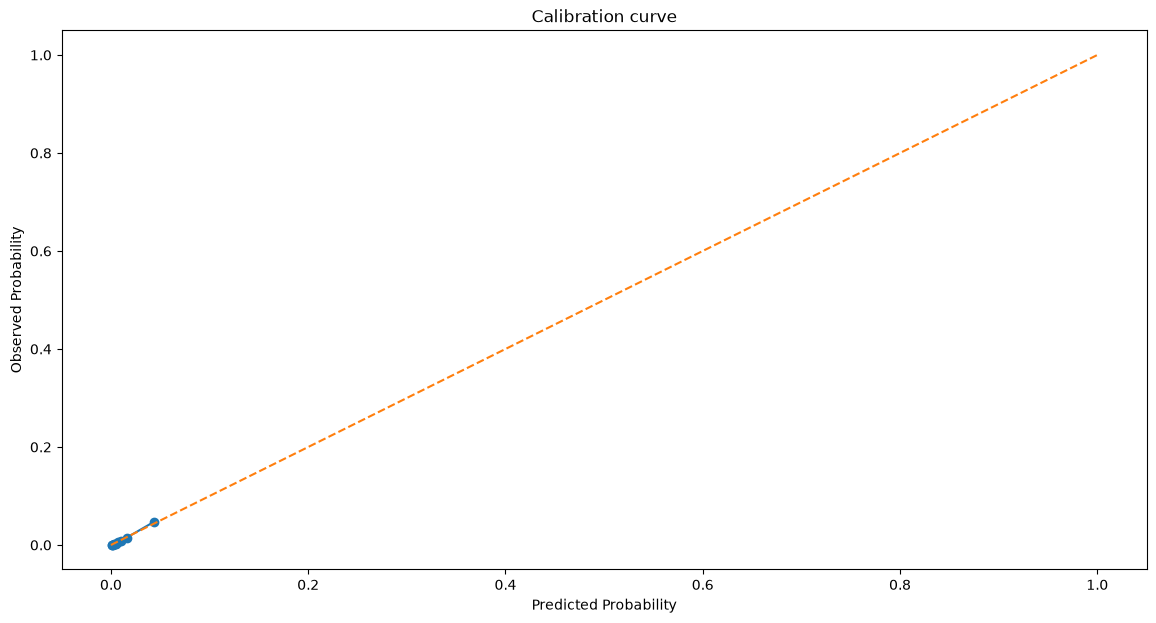

                        Feature  Coefficient
0                      num__age     0.969601
16           bin__heart_disease     0.722469
14                bin__diabetes     0.702457
13           bin__smoker_status     0.654660
15            bin__hypertension     0.444651
17     bin__respiratory_disease     0.376478
18          bin__cancer_history     0.276557
1                      num__bmi     0.030348
11      cat__exercise_level_Low    -0.252407
4     cat__occupation_risk_High    -0.278811
7        cat__alcohol_use_Heavy    -0.502064
8     cat__alcohol_use_Moderate    -0.756254
12   cat__exercise_level_Medium    -0.799140
6   cat__occupation_risk_Medium    -0.918634
9   cat__alcohol_use_No Alcohol    -0.931463
5      cat__occupation_risk_Low    -0.992336
3              cat__gender_Male    -1.025120
10     cat__exercise_level_High    -1.138235
2            cat__gender_Female    -1.164662


In [92]:
## Logistic regression model_2 with class_weight = None

log_reg_2 = LogisticRegression(
    class_weight=None,
    max_iter=5000,
    random_state=42
)

# Defining the pipeline
pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", log_reg_2)
])

# fitting the model
pipeline2.fit(X_train, y_train)

# generating predictions
y_pred2 = pipeline2.predict(X_test)
y_prob2 = pipeline2.predict_proba(X_test)[:, 1]

# calculating roc-auc score
roc_auc2 = roc_auc_score(y_test, y_prob2)
print("ROC-AUC:", roc_auc2)

# calculating pr-auc score
pr_auc2 = average_precision_score(y_test, y_prob2)
print("PR-AUC:",pr_auc2)

# calculating brier score loss
brier2 = brier_score_loss(y_test, y_prob2)
print("Brier score:",brier2)

# classification report
print(classification_report(y_test,y_pred2))

# confusion matrix
print(confusion_matrix(y_test, y_pred2))

# plotting the calibration curve
prob_true2, prob_pred2 = calibration_curve(y_test, y_prob2, n_bins=10, strategy="quantile")

plt.figure(figsize=(14,7))
plt.plot(prob_pred2, prob_true2, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration curve")
plt.show()

# extracting features and inspecting coefficients
feature_names2 = (
    pipeline2.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients2 = (
    pipeline2.named_steps["classifier"]
    .coef_[0]
)

coef_df2 = pd.DataFrame({
    "Feature": feature_names2,
    "Coefficient": coefficients2
})

coef_df2 = coef_df2.sort_values(
    "Coefficient",
    ascending=False
)

print(coef_df2.head(20))

In [70]:
print(pd.Series(y_prob2).describe())

print(pd.Series(y_prob2).quantile(
    [0.5,0.75,0.9,0.95,0.99,0.999]
))

count    10000.000000
mean         0.009118
std          0.015517
min          0.000201
25%          0.001911
50%          0.004256
75%          0.009733
max          0.285638
dtype: float64
0.500    0.004256
0.750    0.009733
0.900    0.021183
0.950    0.033274
0.990    0.076754
0.999    0.167206
dtype: float64


In [71]:
results = pd.DataFrame({
    "actual": y_test,
    "prob": y_prob2
})

results["decile"] = pd.qcut(
    results["prob"],
    10,
    labels=False
)

summary = (
    results.groupby("decile")
    .agg(
        count=("actual","count"),
        deaths=("actual","sum"),
        avg_prob=("prob","mean")
    )
)

print(summary)

        count  deaths  avg_prob
decile                         
0        1000       0  0.000642
1        1000       1  0.001256
2        1000       1  0.001922
3        1000       2  0.002687
4        1000       3  0.003658
5        1000       2  0.004954
6        1000       7  0.006874
7        1000       8  0.009869
8        1000      15  0.015914
9        1000      47  0.043400


In [72]:
## Adding bmi ** 2 column to the data to better fit the logistic regression

mortality_training_data['bmi_squared'] = mortality_training_data['bmi'] ** 2

In [82]:
features_new = [
    "age",
    "bmi",
    "bmi_squared",
    "gender",
    "occupation_risk",
    "alcohol_use",
    "exercise_level",
    "smoker_status",
    "diabetes",
    "hypertension",
    "heart_disease",
    "respiratory_disease",
    "cancer_history"
]

target = "mortality_event"

X_new = mortality_training_data[features_new]
y_new = mortality_training_data[target]

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

print(y_new_train.value_counts(normalize=True))
print(y_new_test.value_counts(normalize=True))

numeric_features = [
    "age",
    "bmi",
    "bmi_squared"
]

categorical_features = [
    "gender",
    "occupation_risk",
    "alcohol_use",
    "exercise_level"
]

binary_features = [
    "smoker_status",
    "diabetes",
    "hypertension",
    "heart_disease",
    "respiratory_disease",
    "cancer_history"
]

mortality_event
0    0.99085
1    0.00915
Name: proportion, dtype: float64
mortality_event
0    0.9914
1    0.0086
Name: proportion, dtype: float64


In [ ]:
# creating a new preprocessor with new features

preprocessor3 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "bin",
            "passthrough",
            binary_features
        )
    ]
)

In [88]:
print(
    pipeline3.named_steps["preprocessor"].get_feature_names_out()
)

['num__age' 'num__bmi' 'num__bmi_squared' 'cat__gender_Female'
 'cat__gender_Male' 'cat__occupation_risk_High' 'cat__occupation_risk_Low'
 'cat__occupation_risk_Medium' 'cat__alcohol_use_Heavy'
 'cat__alcohol_use_Moderate' 'cat__alcohol_use_No Alcohol'
 'cat__exercise_level_High' 'cat__exercise_level_Low'
 'cat__exercise_level_Medium' 'bin__smoker_status' 'bin__diabetes'
 'bin__hypertension' 'bin__heart_disease' 'bin__respiratory_disease'
 'bin__cancer_history']


ROC-AUC: 0.8455725049378141
PR-AUC: 0.10837063678406438
Brier score: 0.008132599667066798


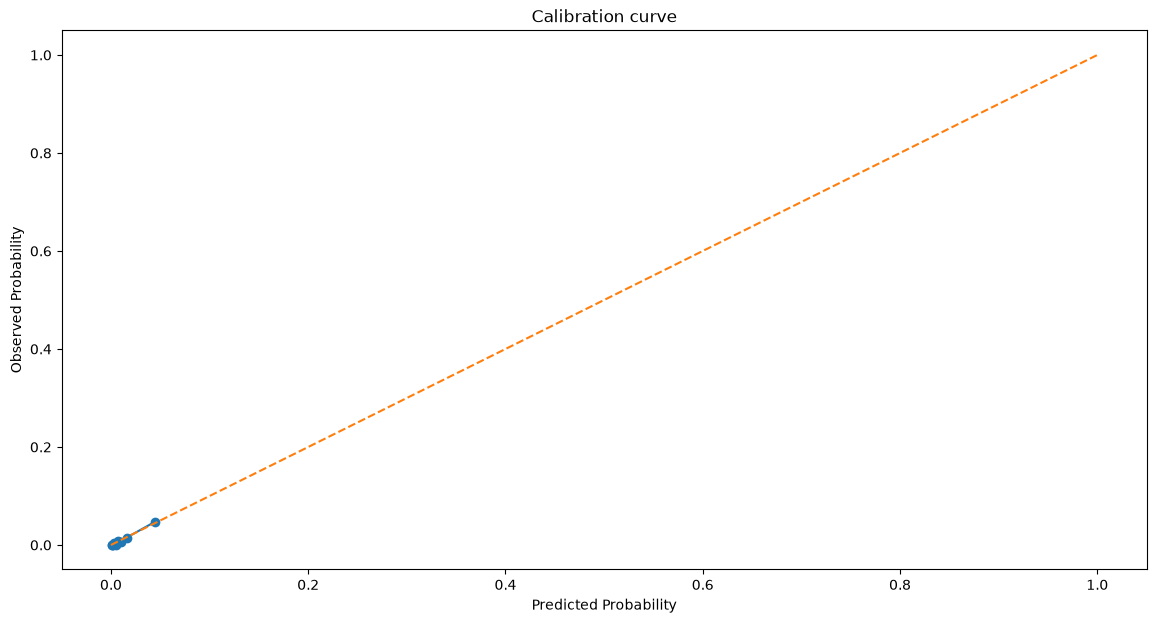

                        Feature  Coefficient
0                      num__age     0.974289
17           bin__heart_disease     0.903904
15                bin__diabetes     0.707219
14           bin__smoker_status     0.596571
2              num__bmi_squared     0.543330
18     bin__respiratory_disease     0.484300
16            bin__hypertension     0.443795
19          bin__cancer_history     0.409178
12      cat__exercise_level_Low    -0.256653
5     cat__occupation_risk_High    -0.257256
8        cat__alcohol_use_Heavy    -0.483427
1                      num__bmi    -0.508905
9     cat__alcohol_use_Moderate    -0.739718
13   cat__exercise_level_Medium    -0.805126
7   cat__occupation_risk_Medium    -0.910886
10  cat__alcohol_use_No Alcohol    -0.931262
6      cat__occupation_risk_Low    -0.986266
4              cat__gender_Male    -1.003977
11     cat__exercise_level_High    -1.092629
3            cat__gender_Female    -1.150431


In [93]:
# Logistic regression model with the new column included

## Logistic regression model_3 with class_weight = None

log_reg_3 = LogisticRegression(
    class_weight=None,
    max_iter=5000,
    random_state=42
)

# Defining the pipeline
pipeline3 = Pipeline([
    ("preprocessor", preprocessor3),
    ("classifier", log_reg_3)
])

# fitting the model
pipeline3.fit(X_new_train, y_new_train)

# generating predictions
y_pred3 = pipeline3.predict(X_new_test)
y_prob3 = pipeline3.predict_proba(X_new_test)[:, 1]

# calculating roc-auc score
roc_auc3 = roc_auc_score(y_new_test, y_prob3)
print("ROC-AUC:", roc_auc3)

# calculating pr-auc score
pr_auc3 = average_precision_score(y_new_test, y_prob3)
print("PR-AUC:",pr_auc3)

# calculating brier score loss
brier3 = brier_score_loss(y_new_test, y_prob3)
print("Brier score:",brier3)

# classification report
# print(classification_report(y_new_test,y_pred3))

# # confusion matrix
# print(confusion_matrix(y_new_test, y_pred3))

# plotting the calibration curve
prob_true3, prob_pred3 = calibration_curve(y_new_test, y_prob3, n_bins=10, strategy="quantile")

plt.figure(figsize=(14,7))
plt.plot(prob_pred3, prob_true3, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration curve")
plt.show()

# extracting features and inspecting coefficients
feature_names3 = (
    pipeline3.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients3 = (
    pipeline3.named_steps["classifier"]
    .coef_[0]
)

coef_df3 = pd.DataFrame({
    "Feature": feature_names3,
    "Coefficient": coefficients3
})

coef_df3 = coef_df3.sort_values(
    "Coefficient",
    ascending=False
)

print(coef_df3.head(20))

In [89]:
print(coef_df3[coef_df3["Feature"].str.contains("bmi")])

            Feature  Coefficient
2  num__bmi_squared     0.543330
1          num__bmi    -0.508905


In [91]:
results = pd.DataFrame({
    "actual": y_new_test,
    "prob": y_prob3
})

results["decile"] = pd.qcut(
    results["prob"],
    10,
    labels=False,
    duplicates="drop"
)

deciles = (
    results.groupby("decile")
    .agg(
        customers=("actual", "count"),
        deaths=("actual", "sum"),
        avg_probability=("prob", "mean")
    )
)

deciles["actual_rate"] = (
    deciles["deaths"] /
    deciles["customers"]
)

print(deciles)

        customers  deaths  avg_probability  actual_rate
decile                                                 
0            1000       0         0.000627        0.000
1            1000       1         0.001227        0.001
2            1000       1         0.001877        0.001
3            1000       2         0.002624        0.002
4            1000       4         0.003586        0.004
5            1000       1         0.004868        0.001
6            1000       8         0.006757        0.008
7            1000       7         0.009738        0.007
8            1000      15         0.015864        0.015
9            1000      47         0.044290        0.047


### Logistic model results:

#### Features:
- age
- bmi
- bmi_squared
- gender
- occupation_risk
- alcohol_use
- exercise_level
- smoker_status
- diabetes
- hypertension
- heart_disease
- respiratory_disease
- cancer_history

#### Performance:
- ROC-AUC: 0.8455725049378141
- PR-AUC: 0.10837063678406438
- Brier score: 0.008132599667066798

---
### Model - 2 HistGradientBoostingClassifier

In [94]:
preprocessor_hgb = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "bin",
            "passthrough",
            binary_features
        )
    ]
)

In [95]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,
    min_samples_leaf=50,
    random_state=42
)

In [96]:
hgb_pipeline = Pipeline([
    ("preprocessor", preprocessor_hgb),
    ("classifier",hgb)
])

In [97]:
hgb_pipeline.fit(X_new_train, y_new_train)

y_pred_new = hgb_pipeline.predict(X_new_test)
y_prob_hgb = hgb_pipeline.predict_proba(X_new_test)[:, 1]

In [98]:
roc_auc_hgb = roc_auc_score(y_new_test, y_prob_hgb)

pr_auc_hgb = average_precision_score(y_new_test, y_prob_hgb)

brier_hgb = brier_score_loss(y_new_test, y_prob_hgb)

print("ROC-AUC:",roc_auc_hgb)
print("PR-AUC:",pr_auc_hgb)
print("Brier:",brier_hgb)

ROC-AUC: 0.8150043865616394
PR-AUC: 0.08764058791304052
Brier: 0.008194522422768552


In [99]:
results_hgb = pd.DataFrame({
    "actual": y_new_test,
    "prob": y_prob_hgb
})

results_hgb["decile"] = pd.qcut(
    results_hgb["prob"],
    10,
    labels=False,
    duplicates="drop"
)

deciles_hgb = (
    results_hgb.groupby("decile")
    .agg(
        customers=("actual","count"),
        deaths=("actual","sum"),
        avg_probability=("prob","mean")
    )
)

deciles_hgb["actual_rate"] = (
    deciles_hgb["deaths"]
    /
    deciles_hgb["customers"]
)

print(deciles_hgb)

        customers  deaths  avg_probability  actual_rate
decile                                                 
0            1001       1         0.002270     0.000999
1             999       1         0.002432     0.001001
2            1002       0         0.002824     0.000000
3             998       4         0.003231     0.004008
4            1000       4         0.003680     0.004000
5            1000       5         0.004781     0.005000
6            1000       7         0.006203     0.007000
7            1000       8         0.008419     0.008000
8            1000      10         0.014198     0.010000
9            1000      46         0.044186     0.046000


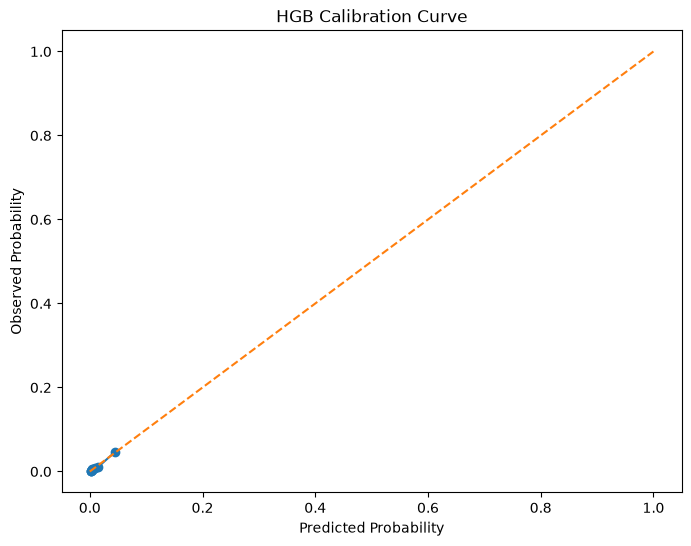

In [100]:
from sklearn.calibration import calibration_curve

prob_true_hgb, prob_pred_hgb = calibration_curve(
    y_new_test,
    y_prob_hgb,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8,6))
plt.plot(prob_pred_hgb, prob_true_hgb, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("HGB Calibration Curve")
plt.show()

In [102]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic",
        "HistGradientBoosting"
    ],
    "ROC_AUC": [
        roc_auc3,
        roc_auc_hgb
    ],
    "PR_AUC": [
        pr_auc3,
        pr_auc_hgb
    ],
    "Brier": [
        brier3,
        brier_hgb
    ]
})

print(comparison)

                  Model   ROC_AUC    PR_AUC     Brier
0              Logistic  0.845573  0.108371  0.008133
1  HistGradientBoosting  0.815004  0.087641  0.008195


### HistGradientBoostingClassifer model results:

#### Features:
- age
- bmi
- bmi_squared
- gender
- occupation_risk
- alcohol_use
- exercise_level
- smoker_status
- diabetes
- hypertension
- heart_disease
- respiratory_disease
- cancer_history

#### Performance:
- ROC-AUC: 0.8150043865616394
- PR-AUC: 0.08764058791304052
- Brier: 0.008194522422768552

---
### Model - 3 Random Forest

In [103]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "bin",
            "passthrough",
            binary_features
        )
    ]
)

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=20
)

In [105]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", rf)
])

In [106]:
rf_pipeline.fit(X_new_train, y_new_train)

y_pred_rf = rf_pipeline.predict(X_new_test)
y_prob_rf = rf_pipeline.predict_proba(X_new_test)[:, 1]

roc_auc_rf = roc_auc_score(y_new_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_new_test, y_prob_rf)
brier_rf = brier_score_loss(y_new_test, y_prob_rf)

print("ROC-AUC:", roc_auc_rf)
print("PR-AUC", pr_auc_rf)
print("Brier score:", brier_rf)

ROC-AUC: 0.8224034839151587
PR-AUC 0.09563840888024558
Brier score: 0.09049948289846671


In [107]:
results_rf = pd.DataFrame({
    "actual": y_new_test,
    "prob": y_prob_rf
})

results_rf["decile"] = pd.qcut(
    results_rf["prob"],
    10,
    labels=False,
    duplicates="drop"
)

deciles_rf = (
    results_rf.groupby("decile")
    .agg(
        customers=("actual","count"),
        deaths=("actual","sum"),
        avg_probability=("prob","mean")
    )
)

deciles_rf["actual_rate"] = (
    deciles_rf["deaths"]
    /
    deciles_rf["customers"]
)

print(deciles_rf)

        customers  deaths  avg_probability  actual_rate
decile                                                 
0            1000       0         0.020536        0.000
1            1000       0         0.046490        0.000
2            1000       3         0.079678        0.003
3            1000       2         0.116106        0.002
4            1000       2         0.152711        0.002
5            1000       5         0.195915        0.005
6            1000       9         0.253442        0.009
7            1000      11         0.337563        0.011
8            1000      11         0.460527        0.011
9            1000      43         0.649758        0.043


In [108]:
feature_names_rf = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances_rf = (
    rf_pipeline.named_steps["classifier"]
    .feature_importances_
)

importance_df_rf = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": importances_rf
})

importance_df_rf = importance_df_rf.sort_values(
    "Importance",
    ascending=False
)

print(importance_df_rf.head(20))

                        Feature  Importance
0                      num__age    0.422733
1                      num__bmi    0.129019
2              num__bmi_squared    0.127575
5     cat__occupation_risk_High    0.037030
14           bin__smoker_status    0.032911
12      cat__exercise_level_Low    0.031579
15                bin__diabetes    0.027388
16            bin__hypertension    0.020618
9     cat__alcohol_use_Moderate    0.020107
6      cat__occupation_risk_Low    0.017588
10  cat__alcohol_use_No Alcohol    0.016234
4              cat__gender_Male    0.016143
3            cat__gender_Female    0.016114
11     cat__exercise_level_High    0.015817
13   cat__exercise_level_Medium    0.015343
17           bin__heart_disease    0.014858
7   cat__occupation_risk_Medium    0.014311
8        cat__alcohol_use_Heavy    0.014145
18     bin__respiratory_disease    0.008964
19          bin__cancer_history    0.001525


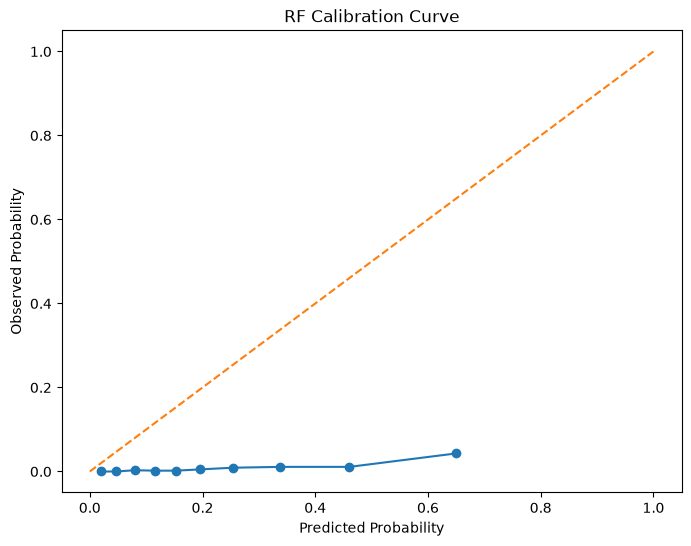

In [110]:
from sklearn.calibration import calibration_curve

prob_true_rf, prob_pred_rf = calibration_curve(
    y_new_test,
    y_prob_rf,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8,6))
plt.plot(prob_pred_rf, prob_true_rf, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("RF Calibration Curve")
plt.show()

In [111]:
comparison_of_three_models = pd.DataFrame({
    "Model": [
        "Logistic",
        "HistGradientBoosting",
        "RandomForestClassifer"
    ],
    "ROC_AUC": [
        roc_auc3,
        roc_auc_hgb,
        roc_auc_rf
    ],
    "PR_AUC": [
        pr_auc3,
        pr_auc_hgb,
        pr_auc_rf
    ],
    "Brier": [
        brier3,
        brier_hgb,
        brier_rf
    ]
})

print(comparison_of_three_models)

                   Model   ROC_AUC    PR_AUC     Brier
0               Logistic  0.845573  0.108371  0.008133
1   HistGradientBoosting  0.815004  0.087641  0.008195
2  RandomForestClassifer  0.822403  0.095638  0.090499


### Random Forest model results:

#### Features:
- age
- bmi
- bmi_squared
- gender
- occupation_risk
- alcohol_use
- exercise_level
- smoker_status
- diabetes
- hypertension
- heart_disease
- respiratory_disease
- cancer_history

#### Performance:
- ROC-AUC: 0.8224034839151587
- PR-AUC 0.09563840888024558
- Brier score: 0.09049948289846671

---

### Comparision of Logistic, HistGradientBoostingClassifer, RandomForestClassifer

```text
S.no |    Model                | ROC_AUC  | PR_AUC   |  Brier
0    |   Logistic              | 0.845573 | 0.108371 | 0.008133
1    |   HistGradientBoosting  | 0.815004 | 0.087641 | 0.008195
2    |   RandomForestClassifer | 0.822403 | 0.095638 | 0.090499
```

we can observe that Logistic model beats the other two models in all three metrics. Therefore we can proceed to verifying the stability of the model and saving it.

---

In [113]:
log_reg_final = LogisticRegression(
    class_weight=None,
    max_iter=5000,
    random_state=42
)

pipeline_final = Pipeline([
    ("preprocessor", preprocessor3),
    ("classifier", log_reg_final)
])

In [116]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier": "neg_brier_score"
}

cv_results = cross_validate(pipeline_final, X_new, y_new, cv=cv, scoring=scoring, n_jobs=1, return_train_score=False)

results_final_df = pd.DataFrame({
    "ROC-AUC": cv_results["test_roc_auc"],
    "PR-AUC": cv_results["test_pr_auc"],
    "Brier": -cv_results["test_brier"]
})

print("results_final_df: ")
print(results_final_df)

summary_final = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Brier"],
    "Mean": [
        results_final_df['ROC-AUC'].mean(),
        results_final_df['PR-AUC'].mean(),
        results_final_df['Brier'].mean()
    ],
    "Std": [
        results_final_df['ROC-AUC'].std(),
        results_final_df['PR-AUC'].std(),
        results_final_df['Brier'].std()
    ]
})

print("summary_final")
print(summary_final)

results_final_df: 
    ROC-AUC    PR-AUC     Brier
0  0.832435  0.079114  0.008673
1  0.814741  0.059793  0.008712
2  0.845575  0.114110  0.008497
3  0.810486  0.093101  0.008641
4  0.781823  0.043815  0.008904
summary_final
    Metric      Mean       Std
0  ROC-AUC  0.817012  0.024185
1   PR-AUC  0.077987  0.027538
2    Brier  0.008685  0.000147


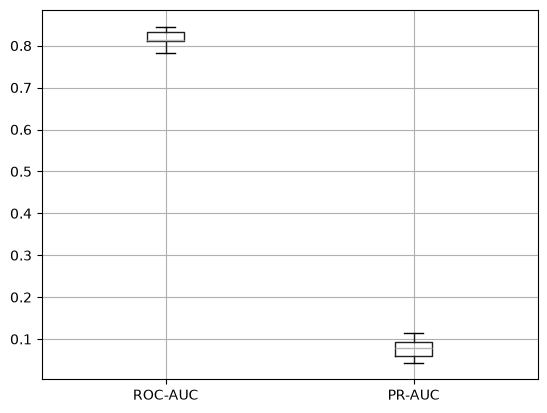

In [117]:
results_final_df.boxplot(column=["ROC-AUC", "PR-AUC"])
plt.show()

#### Result
We can observe that there is no significant difference between the metrics of each fold.
Therefore we can proceed to saving the model.

---
### Saving the model

In [121]:
X_final = mortality_training_data[features_new]
y_final = mortality_training_data[target]

final_model = Pipeline([
    ("preprocessor", preprocessor3),
    ("classifier", LogisticRegression(class_weight=None, max_iter=5000, random_state=42))
])

final_model.fit(X_final, y_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','bmi','bmi_squared',...,'heart_disease','respiratory_disease', 'cancer_history']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [ ]:
## Saving the model as joblib dump and json artifacts

import joblib
import json
from pathlib import Path

# Create directories if they don't exist
models_dir = Path("backend\\models")
artifacts_dir = Path("backend\\artifacts")

models_dir.mkdir(exist_ok=True)
artifacts_dir.mkdir(exist_ok=True)

# --------------------------------------------------
# Saving the model
# --------------------------------------------------

joblib.dump(
    final_model,
    models_dir / "mortality_prediction_model_v1.joblib"
)

# --------------------------------------------------
# Saving the feature schema
# --------------------------------------------------

feature_schema = {
    "numeric": ["age", "bmi", "bmi_squared"],
    "categorical": ["gender", "occupation_risk", "alcohol_use", "exercise_level"],
    "binary": ["smoker_status", "diabetes", "hypertension", "heart_disease", "respiratory_disease", "cancer_history"],
    "target": "mortality_event"
}

with open(artifacts_dir / "feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=4)

# --------------------------------------------------
# Saving metrics
# --------------------------------------------------

metrics = {
    "model_name": "Mortality Prediction Model V1",
    "algorithm": "Logistic Regression",

    "cv_roc_auc_mean": 0.817012,
    "cv_roc_auc_std": 0.024185,

    "cv_pr_auc_mean": 0.077987,
    "cv_pr_auc_std": 0.027538,

    "cv_brier_mean": 0.008685,
    "cv_brier_std": 0.000147
}

with open(artifacts_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# --------------------------------------------------
# Saving metadata
# --------------------------------------------------

metadata = {
    "model_version": "1.0",
    "model_type": "mortality_prediction",

    "algorithm": "LogisticRegression",

    "training_rows": len(X_final),

    "features": features_new,

    "target": "mortality_event",

    "event_rate": float(y_final.mean()),

    "cross_validation": {
        "folds": 5,
        "strategy": "StratifiedKFold",
        "shuffle": True,
        "random_state": 42
    }
}

with open(artifacts_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# --------------------------------------------------
# Saving risk thresholds
# --------------------------------------------------

risk_thresholds = {
    "low": {
        "min": 0.000,
        "max": 0.005
    },
    "medium": {
        "min": 0.005,
        "max": 0.020
    },
    "high": {
        "min": 0.020,
        "max": 0.050
    },
    "severe": {
        "min": 0.050,
        "max": 1.000
    }
}

with open(artifacts_dir / "risk_thresholds.json", "w") as f:
    json.dump(risk_thresholds, f, indent=4)

print("Artifacts saved successfully.")
print(f"Model: {models_dir / 'mortality_prediction_model_v1.joblib'}")
print(f"Artifacts folder: {artifacts_dir}")

Artifacts saved successfully.
Model: Models\mortality_prediction_model_v1.joblib
Artifacts folder: Artifacts
